# Pipeline de Segmentation par Watershed

1. Extraction du masque des grains (seuillage > 0)
2. Extraction des centres des grains (max locaux sur 3x3 pour les pixels à l'intérieur du masque)
3. Labelisation des centres avec numérotation arbitraire
4. Propagation des labels par watershed en utilisant la fonction distance comme carte de priorité
5. Masquage final du résultat de la propagation par le masque des grains

(Comme expliqué par David dans le discord)

In [6]:
import numpy as np
import tifffile
import matplotlib.pyplot as plt
from scipy import ndimage
from skimage.segmentation import watershed
from skimage.feature import peak_local_max
from mpl_toolkits.mplot3d import Axes3D
import os

from watershed_segmentation import watershed_segmentation, process_distance_map_file

## 1. Charger une carte de distance

In [7]:
# Charger la carte de distance (ground truth)
distance_file = "dataset/truth/heightmap.tif"

if os.path.exists(distance_file):
    distance_map = tifffile.imread(distance_file)
    # Convertir de uint16 vers float
    distance_map = distance_map.astype(np.float64) / 65535.0
    print(f"Carte de distance chargée: {distance_map.shape}")
    print(f"Plage de valeurs: [{distance_map.min():.4f}, {distance_map.max():.4f}]")
else:
    print(f"Fichier non trouvé: {distance_file}")
    print("Veuillez d'abord exécuter dem2gt_distance_spam.py")

Carte de distance chargée: (849, 849, 849)
Plage de valeurs: [0.0000, 0.0004]


## 2. Visualiser une coupe de la carte de distance

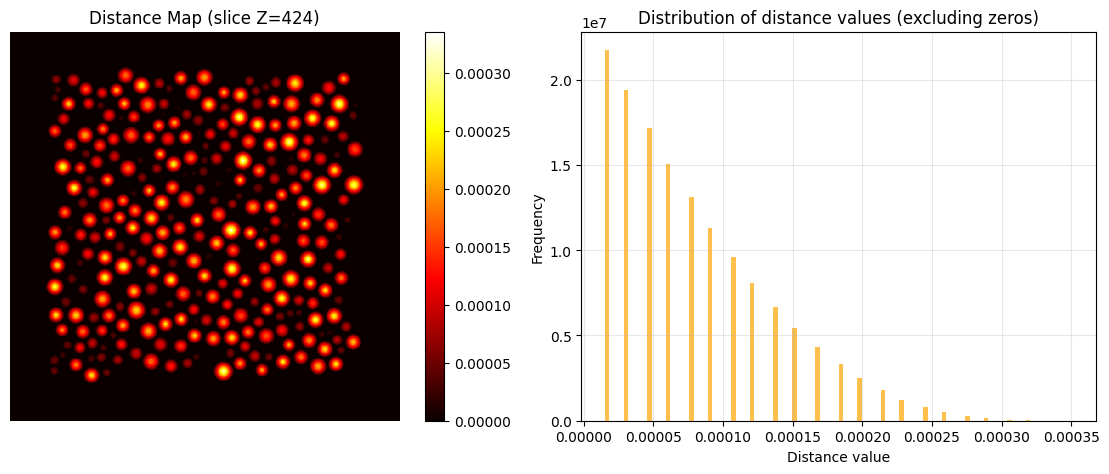

In [8]:
slice_idx = distance_map.shape[0] // 2

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

im1 = axes[0].imshow(distance_map[slice_idx], cmap='hot', interpolation='nearest')
axes[0].set_title(f'Distance Map (slice Z={slice_idx})')
axes[0].axis('off')
plt.colorbar(im1, ax=axes[0], fraction=0.046)

axes[1].hist(distance_map[distance_map > 0].flatten(), bins=100, color='orange', alpha=0.7)
axes[1].set_xlabel('Distance value')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of distance values (excluding zeros)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Appliquer la pipeline de segmentation

In [ ]:
MIN_DISTANCE = 3  # Distance minimale entre centres de grains (en pixels)

labels, num_grains, grain_mask = watershed_segmentation(
    distance_map,
    min_distance=MIN_DISTANCE,
    verbose=True
)

print(f"\n{'='*60}")
print(f"Résultats de la segmentation:")
print(f"  Nombre de grains détectés: {num_grains}")
print(f"  Labels uniques: {np.unique(labels).size}")
print(f"  Taille du volume: {labels.shape}")
print(f"{'='*60}")

Step 1: Extracting grain mask...
  Grain mask contains 771,499 voxels (42.49%)
Step 2: Detecting grain centers (local maxima)...
  Found 5459 local maxima (grain centers)
Step 3: Labeling grain centers...
  Created 5459 labeled markers
Step 4: Propagating labels with watershed...
  Watershed completed in 0.73s
Step 5: Applying final mask...
Segmentation complete!
  Total grains detected: 5459
  Total time: 0.73s

Résultats de la segmentation:
  Nombre de grains détectés: 5459
  Labels uniques: 5460
  Taille du volume: (122, 122, 122)


## 4. Visualiser les étapes de la pipeline

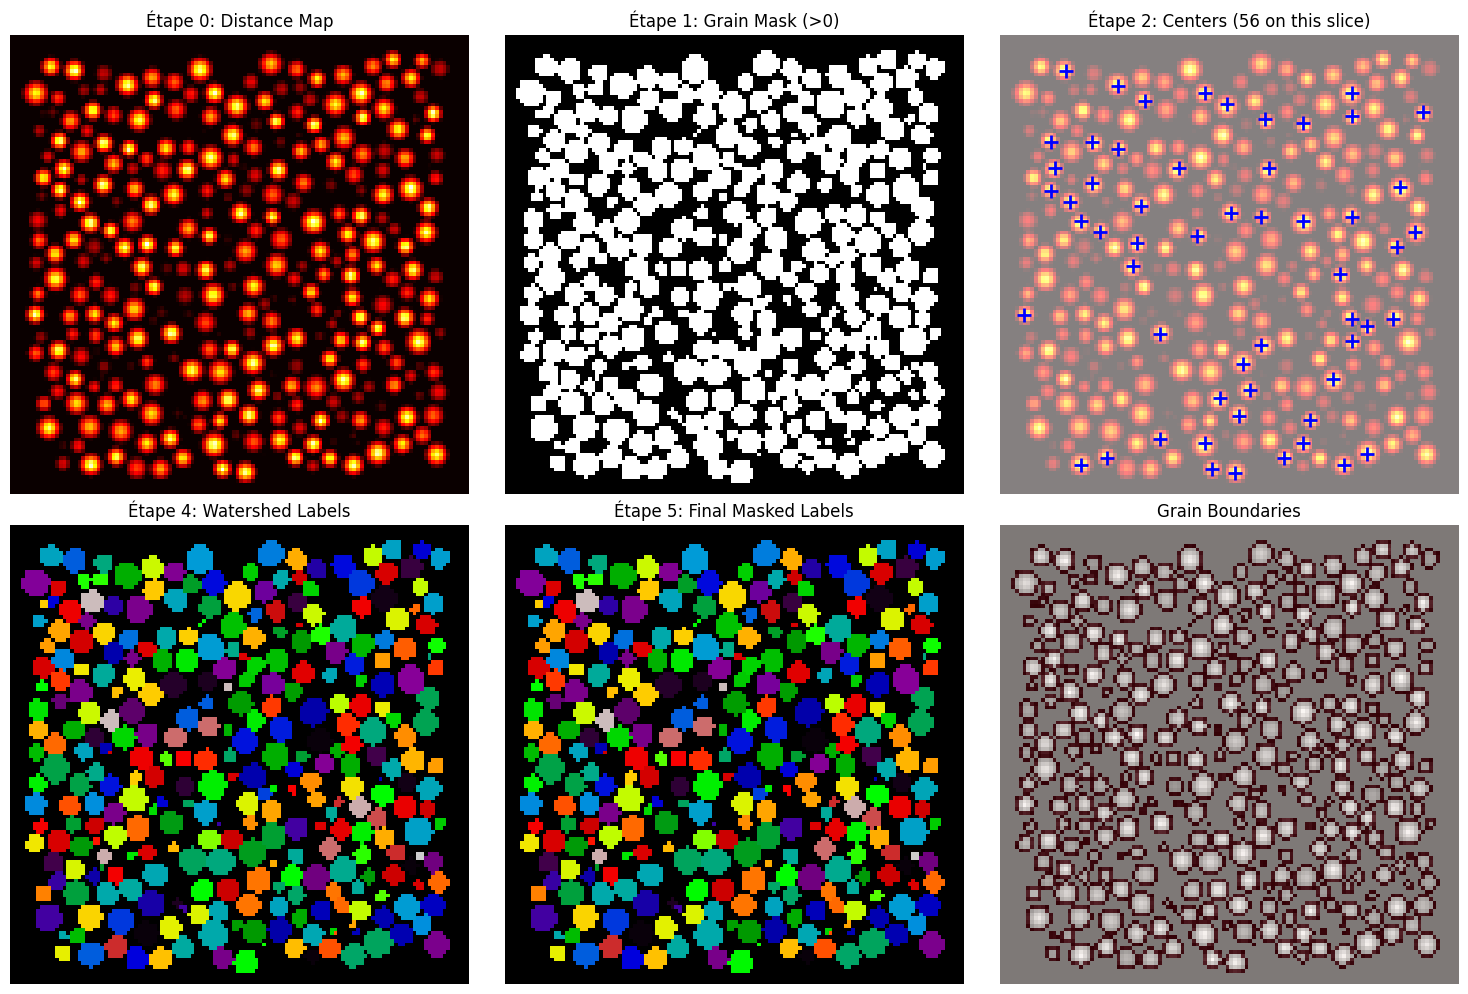

In [ ]:
mask = distance_map > 0

coordinates = peak_local_max(
    distance_map,
    min_distance=MIN_DISTANCE,
    labels=mask.astype(int),
    exclude_border=False
)

centers_image = np.zeros_like(distance_map)
for coord in coordinates:
    centers_image[tuple(coord)] = 1

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

slice_idx = distance_map.shape[0] // 2

axes[0, 0].imshow(distance_map[slice_idx], cmap='hot', interpolation='nearest')
axes[0, 0].set_title('Étape 0: Distance Map')
axes[0, 0].axis('off')

axes[0, 1].imshow(mask[slice_idx], cmap='gray', interpolation='nearest')
axes[0, 1].set_title('Étape 1: Grain Mask (>0)')
axes[0, 1].axis('off')

axes[0, 2].imshow(distance_map[slice_idx], cmap='hot', interpolation='nearest', alpha=0.5)
centers_on_slice = coordinates[coordinates[:, 0] == slice_idx]
if len(centers_on_slice) > 0:
    axes[0, 2].plot(centers_on_slice[:, 2], centers_on_slice[:, 1], 'b+', markersize=10, markeredgewidth=2)
axes[0, 2].set_title(f'Étape 2: Centers ({len(centers_on_slice)} on this slice)')
axes[0, 2].axis('off')

im = axes[1, 0].imshow(labels[slice_idx], cmap='nipy_spectral', interpolation='nearest')
axes[1, 0].set_title('Étape 4: Watershed Labels')
axes[1, 0].axis('off')

masked_labels = labels[slice_idx] * mask[slice_idx]
axes[1, 1].imshow(masked_labels, cmap='nipy_spectral', interpolation='nearest')
axes[1, 1].set_title('Étape 5: Final Masked Labels')
axes[1, 1].axis('off')

from skimage.segmentation import find_boundaries
boundaries = find_boundaries(labels[slice_idx], mode='inner')
axes[1, 2].imshow(distance_map[slice_idx], cmap='gray', interpolation='nearest')
axes[1, 2].imshow(boundaries, cmap='Reds', alpha=0.5, interpolation='nearest')
axes[1, 2].set_title('Grain Boundaries')
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

## 5. Statistiques sur les grains segmentés

Statistiques sur les grains:
  Nombre total de grains: 5459
  Volume moyen: 141.3 voxels
  Volume min/max: 72/382 voxels
  Écart-type: 50.6 voxels


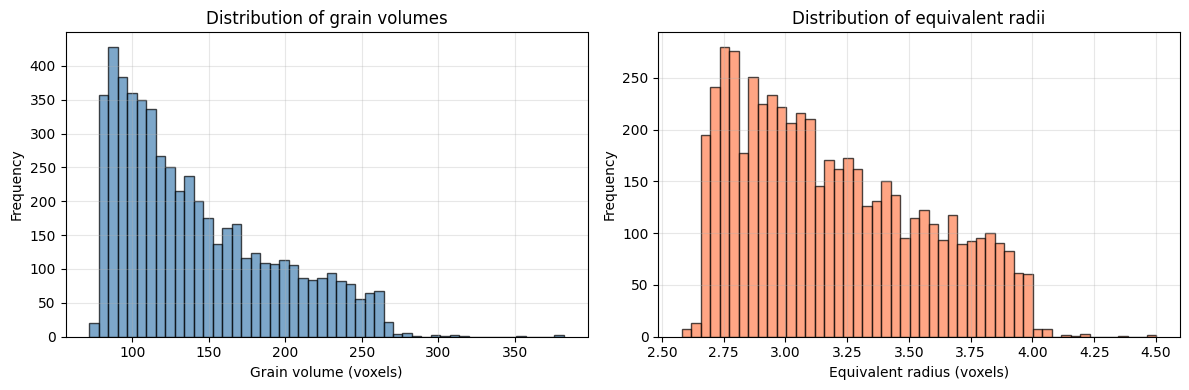

In [ ]:
from scipy.ndimage import center_of_mass, labeled_comprehension

grain_volumes = np.bincount(labels.flatten())[1:]  # Exclure le background (label 0)

print(f"Statistiques sur les grains:")
print(f"  Nombre total de grains: {num_grains}")
print(f"  Volume moyen: {grain_volumes.mean():.1f} voxels")
print(f"  Volume min/max: {grain_volumes.min()}/{grain_volumes.max()} voxels")
print(f"  Écart-type: {grain_volumes.std():.1f} voxels")

# Histogramme des volumes
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(grain_volumes, bins=50, color='steelblue', alpha=0.7, edgecolor='black')
axes[0].set_xlabel('Grain volume (voxels)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of grain volumes')
axes[0].grid(True, alpha=0.3)

# Rayon équivalent (approximation sphérique)
grain_radii = (3 * grain_volumes / (4 * np.pi)) ** (1/3)
axes[1].hist(grain_radii, bins=50, color='coral', alpha=0.7, edgecolor='black')
axes[1].set_xlabel('Equivalent radius (voxels)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of equivalent radii')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Créer un GIF animé des résultats

GIF sauvegardé: watershed_segmentation.gif


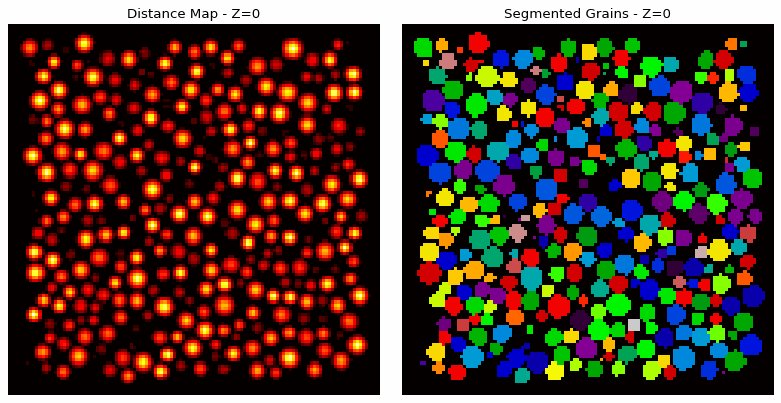

In [ ]:
import imageio.v2 as imageio
from IPython.display import Image as IPyImage
import io

def create_segmentation_gif(distance_map, labels, output_file="segmentation_result.gif", fps=10):
    frames = []
    
    for z in range(distance_map.shape[0]):
        fig, axes = plt.subplots(1, 2, figsize=(10, 5))
        
        # Distance map
        axes[0].imshow(distance_map[z], cmap='hot', interpolation='nearest')
        axes[0].set_title(f'Distance Map - Z={z}')
        axes[0].axis('off')
        
        # Labels
        axes[1].imshow(labels[z], cmap='nipy_spectral', interpolation='nearest')
        axes[1].set_title(f'Segmented Grains - Z={z}')
        axes[1].axis('off')
        
        plt.tight_layout()
        
        # Convertir en image
        buf = io.BytesIO()
        plt.savefig(buf, format='png', dpi=80, bbox_inches='tight')
        buf.seek(0)
        frames.append(imageio.imread(buf))
        plt.close()
    
    # Sauvegarder le GIF
    imageio.mimsave(output_file, frames, fps=fps, loop=0)
    print(f"GIF sauvegardé: {output_file}")
    
    return output_file

crop_size = 50
start_idx = distance_map.shape[0] // 2 - crop_size // 2
end_idx = start_idx + crop_size

gif_file = create_segmentation_gif(
    distance_map[start_idx:end_idx],
    labels[start_idx:end_idx],
    output_file="watershed_segmentation.gif",
    fps=10
)

# Afficher le GIF
display(IPyImage(filename=gif_file))

## 7. Sauvegarder les résultats

In [ ]:
output_folder = "dataset/segmented/"
if not os.path.exists(output_folder):
    os.makedirs(output_folder)
    print(f"Dossier créé: {output_folder}")

output_file = output_folder + "triax.0.eps=-0.0025.spheres_segmented.tif"
tifffile.imwrite(output_file, labels.astype(np.int32))
print(f"Labels sauvegardés: {output_file}")

mask_file = output_folder + "triax.0.eps=-0.0025.spheres_mask.tif"
tifffile.imwrite(mask_file, grain_mask.astype(np.uint8) * 255)
print(f"Masque sauvegardé: {mask_file}")

Labels sauvegardés: dataset/segmented/triax.0.eps=-0.0025.spheres_segmented.tif
Masque sauvegardé: dataset/segmented/triax.0.eps=-0.0025.spheres_mask.tif


## 8. Traitement en batch de tous les fichiers

In [ ]:
from watershed_segmentation import batch_process

batch_process(
    folder_gt="dataset/ground_truth/",
    folder_output="dataset/segmented/",
    min_distance=3
)

Found 14 files to process

Watershed Segmentation Pipeline
Input file: dataset/ground_truth/triax.0.eps=-0.0025.spheres_ground_truth.tif
Loading distance map...
  Shape: (122, 122, 122)
  Data type: float64
  Value range: [0.0000, 0.9941]
Step 1: Extracting grain mask...
  Grain mask contains 771,499 voxels (42.49%)
Step 2: Detecting grain centers (local maxima)...
  Found 5459 local maxima (grain centers)
Step 3: Labeling grain centers...
  Created 5459 labeled markers
Step 4: Propagating labels with watershed...
  Watershed completed in 0.78s
Step 5: Applying final mask...
Segmentation complete!
  Total grains detected: 5459
  Total time: 0.78s
Saving segmentation results...
Saved to: dataset/segmented/triax.0.eps=-0.0025.spheres_segmented.tif

Watershed Segmentation Pipeline
Input file: dataset/ground_truth/triax.5.eps=-0.04.spheres_ground_truth.tif
Loading distance map...
  Shape: (124, 124, 124)
  Data type: float64
  Value range: [0.0000, 0.9870]
Step 1: Extracting grain mask...


## 9. Comparer avec les vraies positions (validation)

Si vous avez les positions réelles des sphères DEM, vous pouvez comparer.

Comparaison avec les vraies données:
  Nombre réel de grains: 5522
  Nombre détecté: 5459
  Différence: 63 grains
  Taux de détection: 98.9%

Rayons réels (en voxels):
  Moyen: 3.18 voxels
  Min/Max: 2.67 / 4.00 voxels


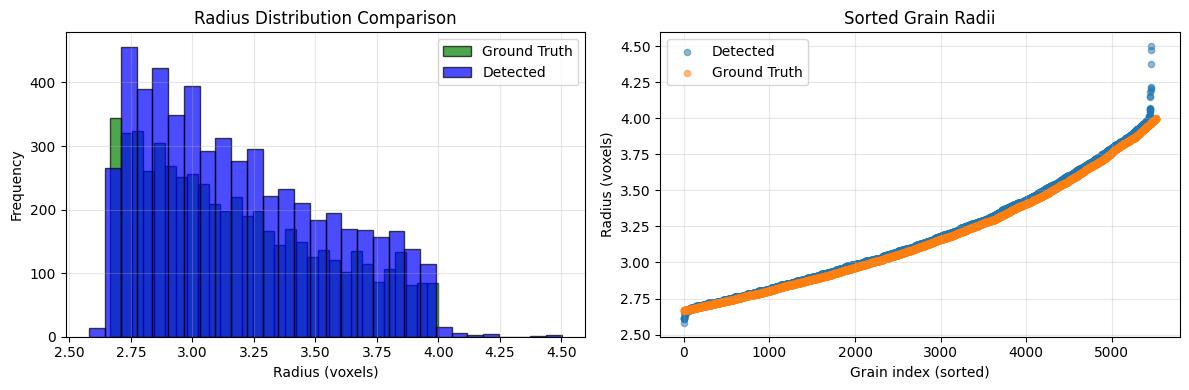

In [ ]:
positions_file = "generate_dataset/dem_data/monotonic/positions/triax.0.eps=-0.0025.spheres.txt"

if os.path.exists(positions_file):
    # Charger les données (colonnes: ID Sphere x y z radius)
    # Les positions sont en MÈTRES, il faut convertir en voxels
    pixel_size = 60e-6  # 60 microns/pixel en mètres
    
    centres = np.loadtxt(positions_file, skiprows=1, usecols=(2,3,4))  # x,y,z en mètres
    radii_meters = np.loadtxt(positions_file, skiprows=1, usecols=(5))  # rayon en mètres
    
    # Convertir en voxels
    radii = radii_meters / pixel_size  # Convertir rayons en voxels
    
    num_real_grains = len(centres)
    
    print(f"Comparaison avec les vraies données:")
    print(f"  Nombre réel de grains: {num_real_grains}")
    print(f"  Nombre détecté: {num_grains}")
    print(f"  Différence: {abs(num_real_grains - num_grains)} grains")
    print(f"  Taux de détection: {num_grains / num_real_grains * 100:.1f}%")
    print(f"\nRayons réels (en voxels):")
    print(f"  Moyen: {radii.mean():.2f} voxels")
    print(f"  Min/Max: {radii.min():.2f} / {radii.max():.2f} voxels")
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    axes[0].hist(radii, bins=30, alpha=0.7, label='Ground Truth', color='green', edgecolor='black')
    axes[0].hist(grain_radii, bins=30, alpha=0.7, label='Detected', color='blue', edgecolor='black')
    axes[0].set_xlabel('Radius (voxels)')
    axes[0].set_ylabel('Frequency')
    axes[0].set_title('Radius Distribution Comparison')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    axes[1].scatter(range(len(grain_radii)), sorted(grain_radii), alpha=0.5, label='Detected', s=20)
    axes[1].scatter(range(len(radii)), sorted(radii), alpha=0.5, label='Ground Truth', s=20)
    axes[1].set_xlabel('Grain index (sorted)')
    axes[1].set_ylabel('Radius (voxels)')
    axes[1].set_title('Sorted Grain Radii')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print(f"Fichier de positions non trouvé: {positions_file}")